# Lab 1A — MNIST Neural Network with Regularization

## Aim

Implement a neural network model on the MNIST dataset to study the effect of regularization techniques by incorporating **L2 regularization and Dropout**, train the model with and without regularization, and compare **accuracy and loss** to study generalization and overfitting.

## 1. Import Libraries

In [1]:
# If TensorFlow is not installed, uncomment the next line and run it once.
%pip install tensorflow matplotlib

import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models, regularizers

print("Libraries imported successfully!")


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Libraries imported successfully!


## 2. Load the MNIST Dataset

MNIST contains handwritten digit images from **0 to 9**. Each image is **28 × 28 pixels**.

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training images:", x_train.shape)
print("Testing images :", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training images: (60000, 28, 28)
Testing images : (10000, 28, 28)


## 3. Display a Sample Image

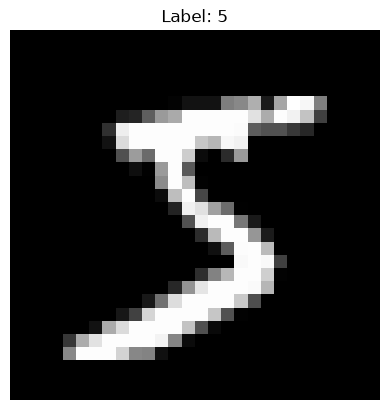

In [3]:
plt.imshow(x_train[0], cmap="gray")
plt.title(f"Label: {y_train[0]}")
plt.axis("off")
plt.show()

## 4. Preprocess the Data

### Normalize pixel values

Pixel values range from **0 to 255**. We convert them to a range between **0 and 1**.

In [4]:
x_train = x_train / 255.0
x_test = x_test / 255.0

### Flatten the images

Each 28 × 28 image is converted into a vector of **784 values**.

In [5]:
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

print("Training data after flattening:", x_train.shape)
print("Testing data after flattening :", x_test.shape)

Training data after flattening: (60000, 784)
Testing data after flattening : (10000, 784)


# Part A — Model Without Regularization

This is the **baseline model**. It does not use L2 regularization or Dropout.

In [6]:
model_without_reg = models.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model_without_reg.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_without_reg.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Train the Model Without Regularization

In [7]:
history_without_reg = model_without_reg.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9232 - loss: 0.2672 - val_accuracy: 0.9639 - val_loss: 0.1260
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9661 - loss: 0.1135 - val_accuracy: 0.9676 - val_loss: 0.1109
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9755 - loss: 0.0791 - val_accuracy: 0.9682 - val_loss: 0.0992
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9813 - loss: 0.0588 - val_accuracy: 0.9697 - val_loss: 0.0998
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9855 - loss: 0.0461 - val_accuracy: 0.9720 - val_loss: 0.1011
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9881 - loss: 0.0367 - val_accuracy: 0.9736 - val_loss: 0.0969
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9895 - loss: 0.0313 - val_accuracy: 0.9704 - val_loss: 0.1090
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9918 - loss: 0.0258 - 

## 6. Evaluate the Model

In [8]:
test_loss, test_accuracy = model_without_reg.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.09755609184503555
Test Accuracy: 0.9757000207901001


## 7. Accuracy — Without Regularization

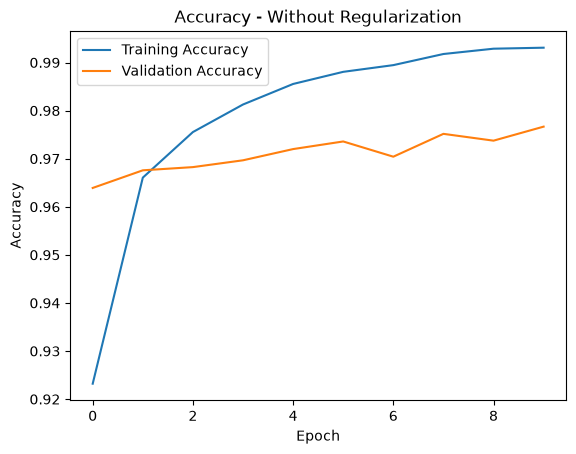

In [9]:
plt.plot(history_without_reg.history["accuracy"], label="Training Accuracy")
plt.plot(history_without_reg.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy - Without Regularization")
plt.legend()
plt.show()

## 8. Loss — Without Regularization

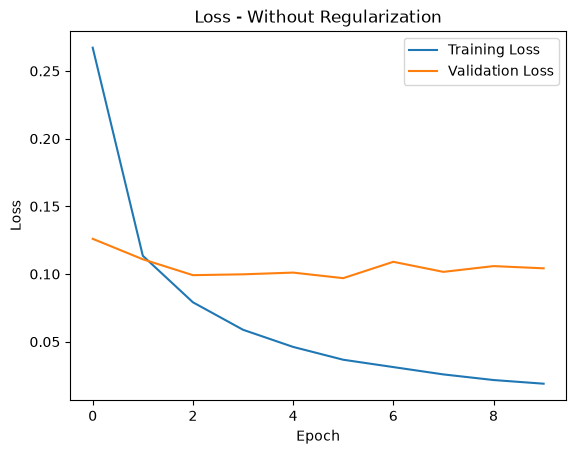

In [10]:
plt.plot(history_without_reg.history["loss"], label="Training Loss")
plt.plot(history_without_reg.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss - Without Regularization")
plt.legend()
plt.show()

# Part B — Model With L2 Regularization and Dropout

**L2 regularization** helps control large weights.

**Dropout** randomly turns off some neurons during training.

These techniques can help reduce overfitting and improve generalization.

In [11]:
model_with_reg = models.Sequential([
    layers.Input(shape=(784,)),

    layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=regularizers.l2(0.001)
    ),
    layers.Dropout(0.3),

    layers.Dense(
        64,
        activation="relu",
        kernel_regularizer=regularizers.l2(0.001)
    ),
    layers.Dropout(0.3),

    layers.Dense(10, activation="softmax")
])

model_with_reg.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_with_reg.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

## 9. Train the Model With L2 + Dropout

In [12]:
history_with_reg = model_with_reg.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8634 - loss: 0.6412 - val_accuracy: 0.9454 - val_loss: 0.3467
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9271 - loss: 0.4041 - val_accuracy: 0.9571 - val_loss: 0.2879
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9380 - loss: 0.3472 - val_accuracy: 0.9616 - val_loss: 0.2631
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9426 - loss: 0.3278 - val_accuracy: 0.9647 - val_loss: 0.2492
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9461 - loss: 0.3136 - val_accuracy: 0.9682 - val_loss: 0.2363
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9470 - loss: 0.3057 - val_accuracy: 0.9630 - val_loss: 0.2449
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9475 - loss: 0.2999 - val_accuracy: 0.9684 - val_loss: 0.2336
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9494 - loss: 0.2945 - 

## 10. Evaluate the Regularized Model

In [13]:
test_loss_reg, test_accuracy_reg = model_with_reg.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss_reg)
print("Test Accuracy:", test_accuracy_reg)

Test Loss: 0.2209307849407196
Test Accuracy: 0.9706000089645386


## 11. Accuracy — With L2 + Dropout

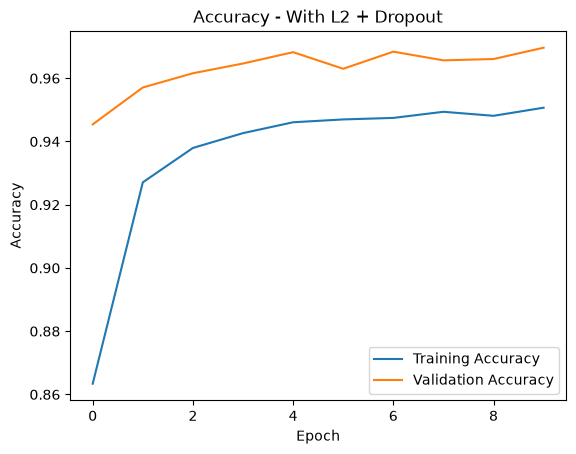

In [14]:
plt.plot(history_with_reg.history["accuracy"], label="Training Accuracy")
plt.plot(history_with_reg.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy - With L2 + Dropout")
plt.legend()
plt.show()

## 12. Loss — With L2 + Dropout

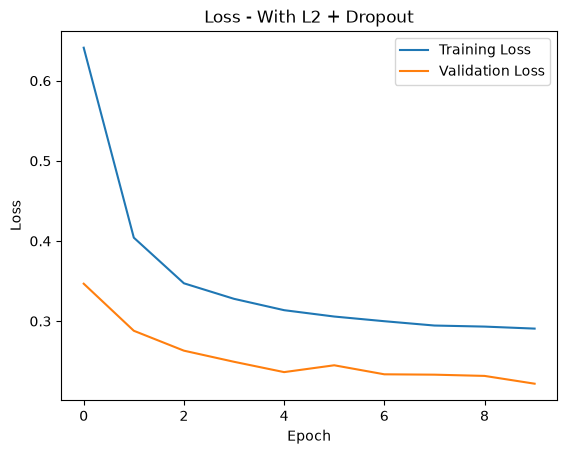

In [15]:
plt.plot(history_with_reg.history["loss"], label="Training Loss")
plt.plot(history_with_reg.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss - With L2 + Dropout")
plt.legend()
plt.show()

# Part C — Comparative Analysis

## 13. Test Accuracy and Loss Comparison

In [16]:
print("Model Comparison")
print("=" * 50)

print(f"{'Metric':<20}{'Without Reg.':<15}{'L2 + Dropout':<15}")
print("-" * 50)
print(f"{'Test Accuracy':<20}{test_accuracy:<15.4f}{test_accuracy_reg:<15.4f}")
print(f"{'Test Loss':<20}{test_loss:<15.4f}{test_loss_reg:<15.4f}")

Model Comparison
Metric              Without Reg.   L2 + Dropout   
--------------------------------------------------
Test Accuracy       0.9757         0.9706         
Test Loss           0.0976         0.2209         


## 14. Validation Accuracy Comparison

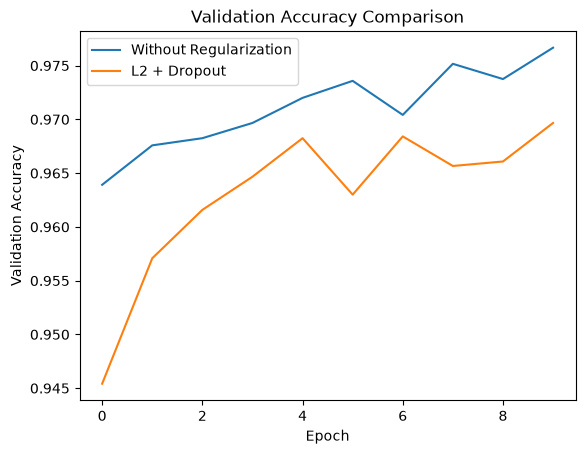

In [17]:
plt.plot(
    history_without_reg.history["val_accuracy"],
    label="Without Regularization"
)

plt.plot(
    history_with_reg.history["val_accuracy"],
    label="L2 + Dropout"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")
plt.legend()
plt.show()

## 15. Validation Loss Comparison

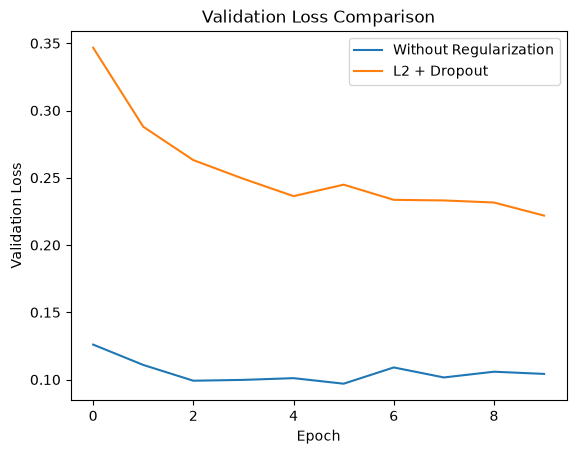

In [18]:
plt.plot(
    history_without_reg.history["val_loss"],
    label="Without Regularization"
)

plt.plot(
    history_with_reg.history["val_loss"],
    label="L2 + Dropout"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison")
plt.legend()
plt.show()

## 16. Observation

Compare the two models using:

- Training accuracy
- Validation accuracy
- Test accuracy
- Training loss
- Validation loss
- Test loss

A large difference between training and validation performance can indicate **overfitting**.

Observe whether L2 regularization and Dropout help control overfitting and improve **generalization**.

## 17. Questions for Analysis

1. Which model achieved higher training accuracy?
2. Which model achieved higher validation accuracy?
3. Which model achieved higher test accuracy?
4. How do the training and validation loss curves differ?
5. Does the regularized model show signs of reduced overfitting?
6. What is the purpose of L2 regularization?
7. What is the purpose of Dropout?

## 18. Conclusion

A neural network was implemented using the MNIST dataset.

Two models were trained:

1. A model **without regularization**.
2. A model using **L2 regularization and Dropout**.

Their accuracy and loss were compared using training, validation, and test results.

The experiment demonstrates how regularization techniques can help control overfitting and improve the model's ability to generalize to unseen data.